# <u>Métodos No Supervisados - Parte 1</u>

## Segmentación K-Means

### Caso:
En una entidad bancaria existen varios canales de comunicación tales como: ATM, Oficinas, IVR, Banca por internet-Móvil, etc.
Sin embargo, al realizar las comunicaciones de ofertas a los clientes de dicha entidad bancaria, el cliente recibe diversas ofertas de distintos canales sin saber si les da importancia o no, por lo que ya interviene un gasto por parte de la entidad, ya que, realiza alianzas estratégicas de campaña.


Por tanto: Se requiere identificar cuál sería el medio de comunicación preferido para los clientes y así enviarles ofertas, advertencia, recordatorios, etc. más direccionadas.

### 1. Librerias

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 4)
plt.style.use('ggplot')

### 2. Extracción Base de datos

In [80]:
dataFrame = pd.read_csv(r"C:\Users\dg_su\OneDrive - Universidad Tecnologica del Peru\Estudios\Cursos\Analisis de Datos\Programa Data Science for Business\codigo\base de datos\01dataBaseMulti.txt",delimiter='|')
print(dataFrame.head())

   cliente       edad      ingreso sexo  flgLimaprov  trxAplus  trxAtm  \
0       28  [7. > 55]   [1. <=700]    M            1       0.0    10.0   
1       44  [7. > 55]  [8. > 8000]    M            1       0.0   125.0   
2       63  [7. > 55]  [3. <=2500]    F            1       0.0    24.0   
3       70  [7. > 55]  [8. > 8000]    M            1       0.0   359.0   
4       77  [7. > 55]  [4. <=3500]    M            1       0.0     8.0   

   trxBcaex  trxBm  trxBxi  trxIvr  trxPostc  trxPostd  trxSalex  trxSbt  \
0       0.0   43.0     5.0     0.0       0.0       1.0      29.0     1.0   
1       0.0    0.0  1679.0     0.0      76.0      21.0       0.0    11.0   
2       0.0    0.0     0.0     0.0       0.0       0.0       2.0     0.0   
3      18.0    0.0     0.0     0.0       0.0     175.0      17.0     8.0   
4       0.0    0.0    23.0     7.0     111.0       0.0       2.0     7.0   

   trxVent   trx  
0      2.0    91  
1      6.0  1918  
2      0.0    26  
3     32.0   609  
4  

In [81]:
print("Número de filas: " + str(dataFrame.shape[0]))
print("Número de columnas: " + str(dataFrame.shape[1]))

Número de filas: 40000
Número de columnas: 17


In [82]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cliente      40000 non-null  int64  
 1   edad         39875 non-null  object 
 2   ingreso      37020 non-null  object 
 3   sexo         39999 non-null  object 
 4   flgLimaprov  40000 non-null  int64  
 5   trxAplus     40000 non-null  float64
 6   trxAtm       40000 non-null  float64
 7   trxBcaex     40000 non-null  float64
 8   trxBm        40000 non-null  float64
 9   trxBxi       40000 non-null  float64
 10  trxIvr       40000 non-null  float64
 11  trxPostc     40000 non-null  float64
 12  trxPostd     40000 non-null  float64
 13  trxSalex     40000 non-null  float64
 14  trxSbt       40000 non-null  float64
 15  trxVent      40000 non-null  float64
 16  trx          40000 non-null  int64  
dtypes: float64(11), int64(3), object(3)
memory usage: 5.2+ MB


### 3. Metodología

In [83]:
#### 3.1 Análisis Previo (objetivo)
#### 3.2 Exploración (descriptivo, grafico barras,cajas)
#### 3.3 Transformación (standarización,cajas)
#### 3.4 Outliers (analisis y eliminación de outliers)
#### 3.5 Dimensionamiento (PCA)
#### 3.6 Modelamiento
#### 3.7 Evaluación
#### 3.8 Perfilamiento
#### 3.9 Visualización

In [84]:
# Variables objetivo de estudio:
channelName = ['trxAplus', 'trxBcaex', 'trxSalex', 'trxBm', 'trxBxi', 'trxIvr', 'trxSbt', 'trxVent',
               'trxAtm','trxPostc', 'trxPostd']

#### 3.1 Análisis Negocio

El dataset ya se encuentra trabajado a nivel de cliente con sus respectivas variables, se consideraron filtros de criterios de autoasignados, distribución histórica de transacciones, etc. 

#### 3.2 Exploración

In [85]:
print(dataFrame[channelName].describe())

           trxAplus      trxBcaex      trxSalex         trxBm        trxBxi  \
count  40000.000000  40000.000000  40000.000000  40000.000000  40000.000000   
mean       0.692650      4.509275      3.303575    227.731450    128.066375   
std        6.230518     11.050313     10.898933    802.171156    552.384436   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      0.000000      0.000000      0.000000      0.000000   
75%        0.000000      4.000000      2.000000     14.000000     32.000000   
max      762.000000    434.000000    523.000000  21210.000000  65309.000000   

             trxIvr        trxSbt       trxVent        trxAtm      trxPostc  \
count  40000.000000  40000.000000  40000.000000  40000.000000  40000.000000   
mean       3.956700      3.364375      2.865125     62.573200      5.897150   
std       15.673606      6.738015      8.973881    

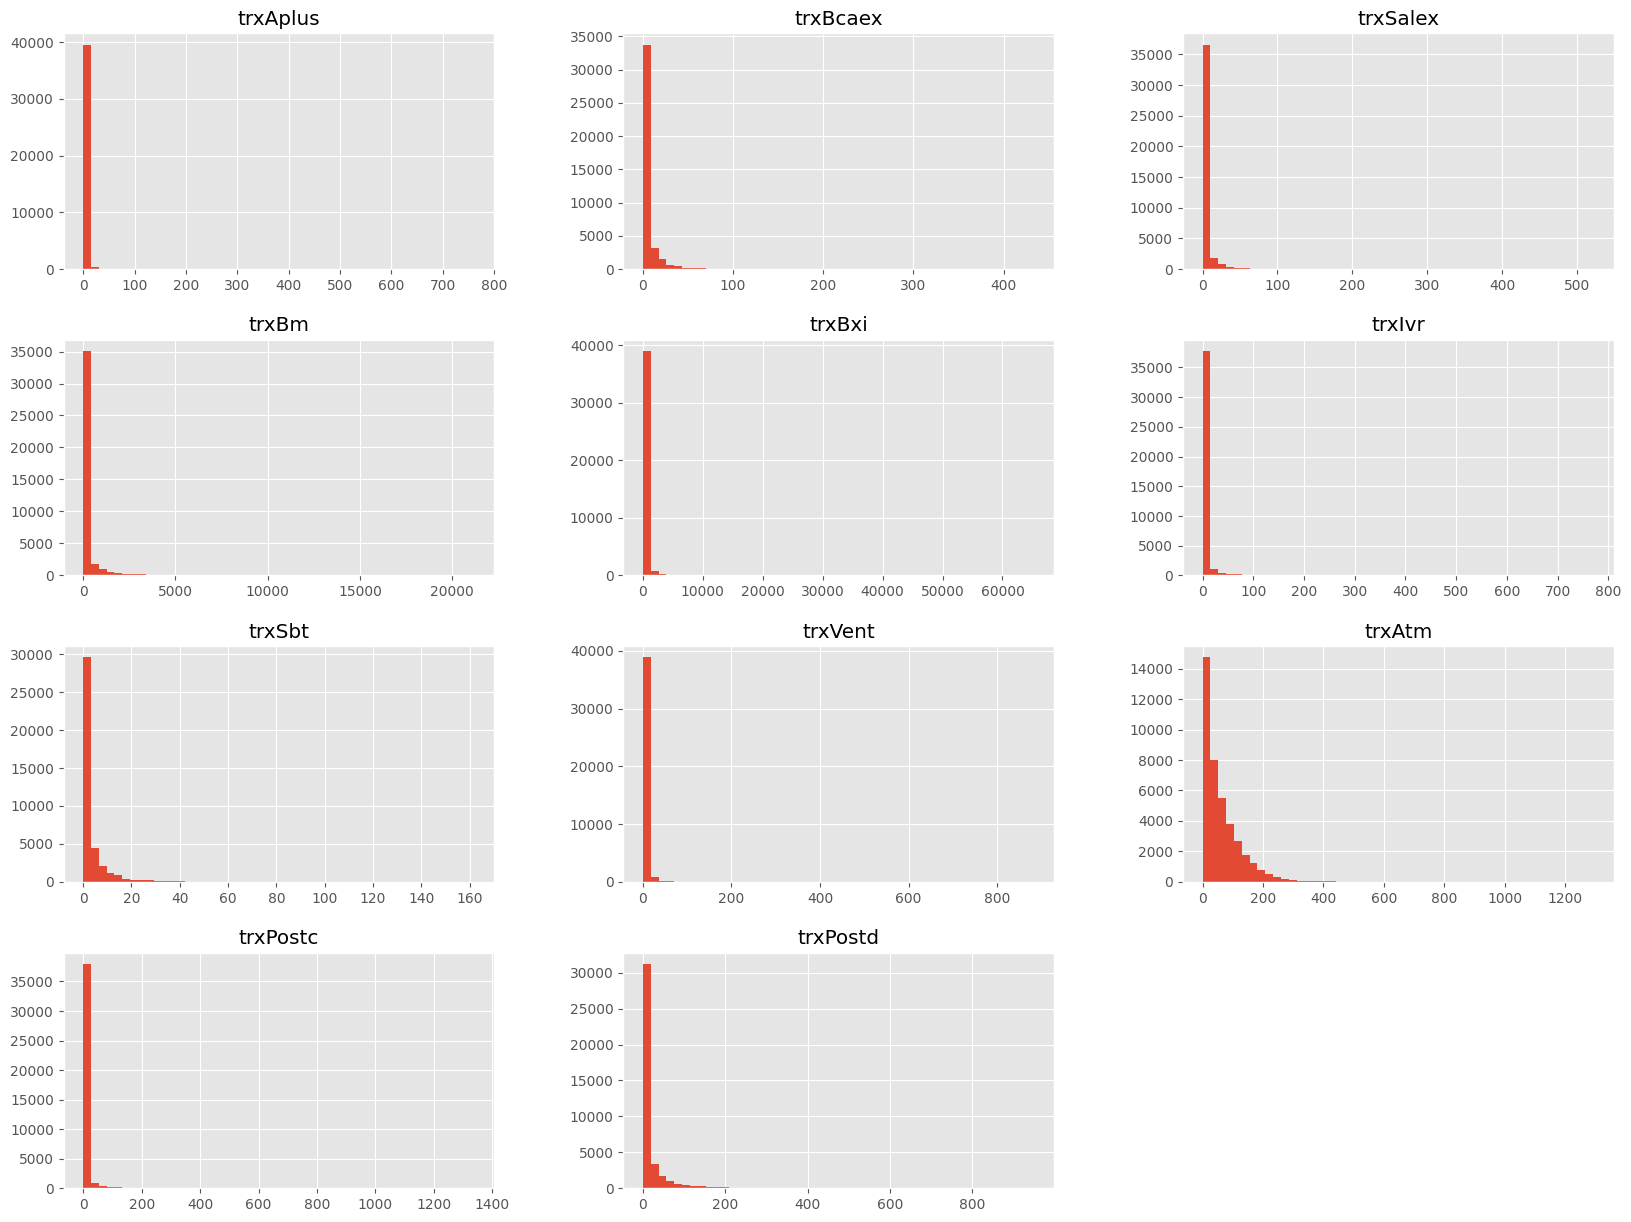

In [86]:
dataFrame[channelName].hist(bins = 50, figsize=(20,15))
plt.show()

Se puede apreciar que la data esta completa, pero esta sesgada hacia los ceros, esto puede generar que la mayoria de los clientes se clasifique hacia un solo canal

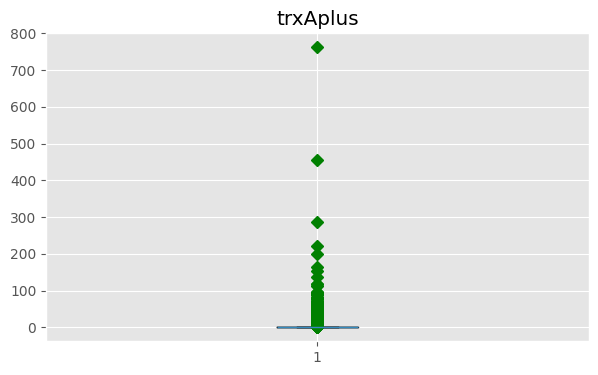

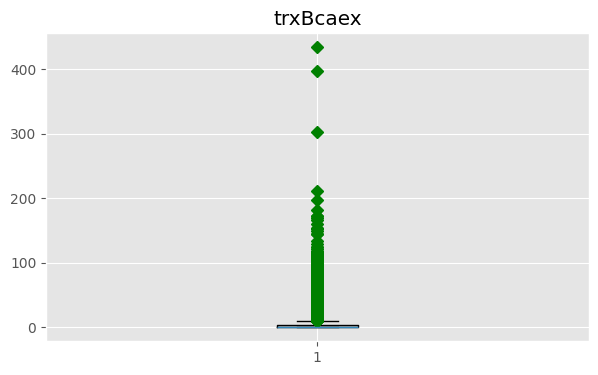

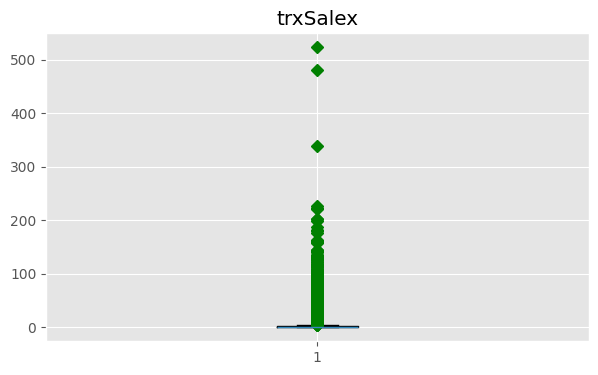

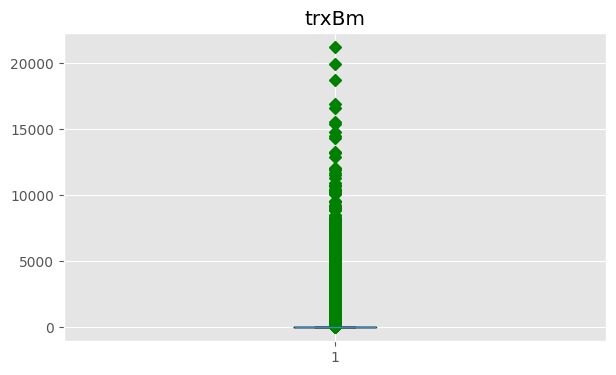

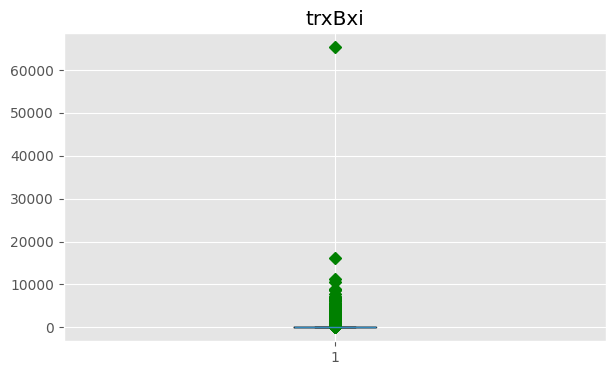

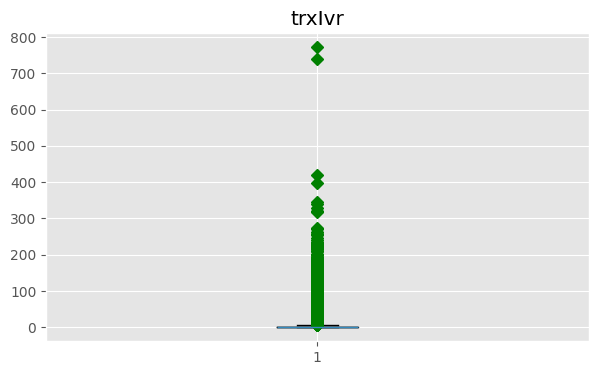

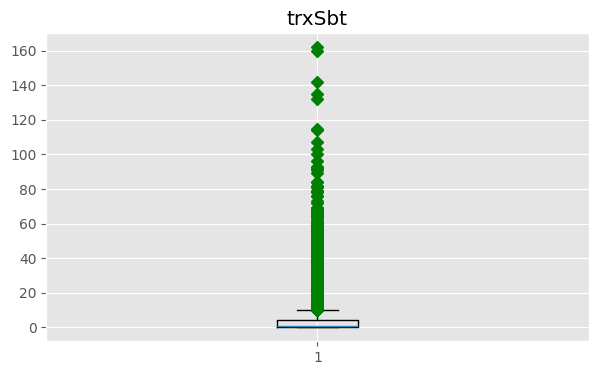

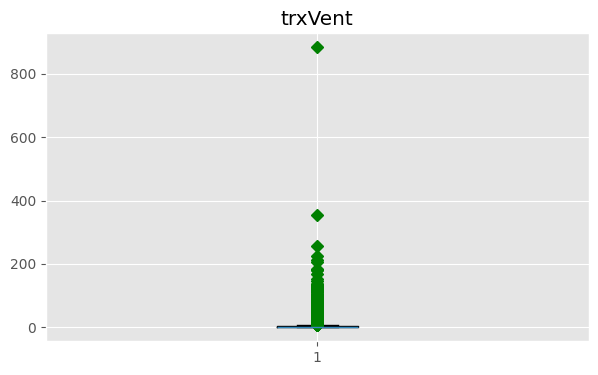

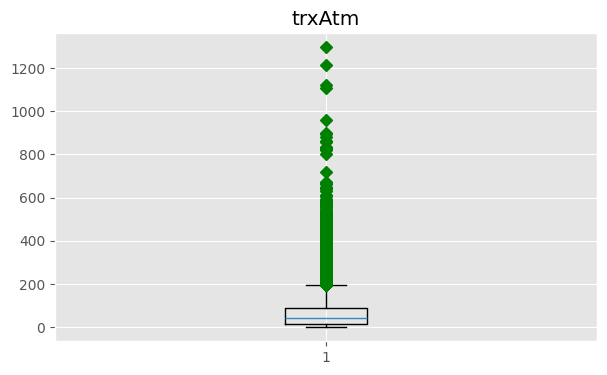

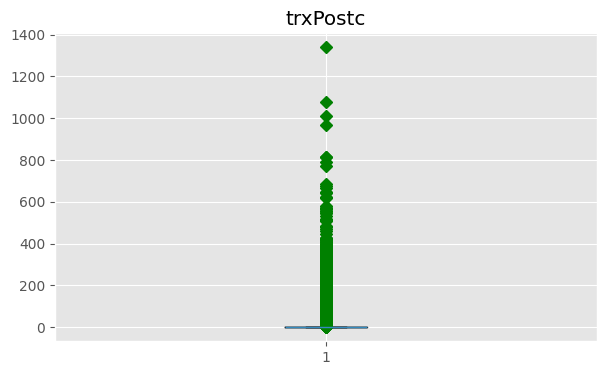

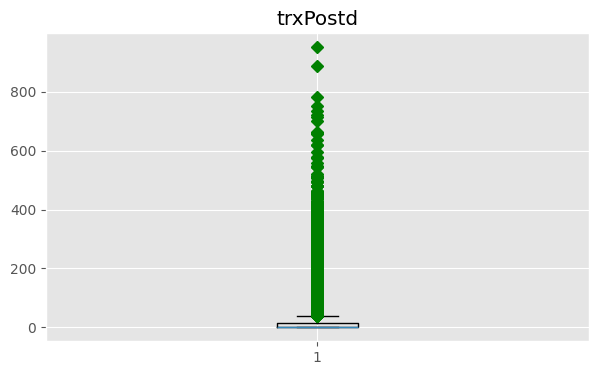

In [87]:
# Gráfico de cajas por variable en estudio:
for columnName in channelName:
    plt.title(columnName)  
    plt.boxplot(dataFrame[columnName], 0, 'gD')    
    plt.show()

#### 3.3 Transformación

In [88]:
# guardamos la data original para poder usar las variables al final
data_orig = dataFrame.copy()

Es recomendable hacer una copia de la data para hacer analisis posteriores

In [89]:
# ------------------------------
# Creamos el objeto para escalar
# ------------------------------
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
#scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))

# ************
# Lo aplicamos
# ************
for columnName in channelName:
    dataFrame[columnName] = scaler.fit_transform(dataFrame[columnName].values.reshape(-1, 1))

#for columnName in columName:
#    dataFrame[columnName] = dataFrame[columnName]/dataFrame['trx']

In [90]:
dataFrame[channelName].head()

,trxAplus,trxBcaex,trxSalex,trxBm,trxBxi,trxIvr,trxSbt,trxVent,trxAtm,trxPostc,trxPostd
0,-0.111172,-0.408073,2.357730,-0.230292,-0.222794,-0.252447,-0.350905,-0.096406,-0.772101,-0.175201,-0.386416
1,-0.111172,-0.408073,-0.303114,-0.283897,2.807742,-0.252447,1.133230,0.349338,0.916813,2.082711,0.048314
2,-0.111172,-0.408073,-0.119607,-0.283897,-0.231846,-0.252447,-0.499319,-0.319278,-0.566494,-0.175201,-0.408153
3,-0.111172,1.220861,1.256691,-0.283897,-0.231846,-0.252447,0.687989,3.246671,4.353387,-0.175201,3.395742
4,-0.111172,-0.408073,-0.119607,-0.283897,-0.190208,0.194170,0.539576,1.017953,-0.801474,3.122538,-0.408153


In [91]:
dataFrame[channelName].describe()

,trxAplus,trxBcaex,trxSalex,trxBm,trxBxi,trxIvr,trxSbt,trxVent,trxAtm,trxPostc,trxPostd
count,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04
mean,-2.842171e-18,3.979039e-17,8.526513e-18,3.410605e-17,2.273737e-17,-2.842171e-18,4.547474e-17,1.705303e-17,5.684342e-18,2.842171e-18,5.684342e-18
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00
min,-1.111719e-01,-4.080727e-01,-3.031137e-01,-2.838974e-01,-2.318457e-01,-2.524467e-01,-4.993188e-01,-3.192778e-01,-9.189633e-01,-1.752005e-01,-4.081530e-01
25%,-1.111719e-01,-4.080727e-01,-3.031137e-01,-2.838974e-01,-2.318457e-01,-2.524467e-01,-4.993188e-01,-3.192778e-01,-6.986701e-01,-1.752005e-01,-4.081530e-01
50%,-1.111719e-01,-4.080727e-01,-3.031137e-01,-2.838974e-01,-2.318457e-01,-2.524467e-01,-3.509052e-01,-2.078419e-01,-3.168286e-01,-1.752005e-01,-3.646799e-01
75%,-1.111719e-01,-4.608751e-02,-1.196072e-01,-2.664445e-01,-1.739143e-01,-1.248420e-01,9.433535e-02,1.502992e-02,3.734234e-01,-1.752005e-01,-8.210490e-02
max,1.221916e+02,3.886732e+01,4.768384e+01,2.615717e+01,1.180007e+02,4.900295e+01,2.354367e+01,9.819005e+01,1.811437e+01,3.960563e+01,2.026330e+01


Se puede apreciar que al hacer la normalizacion standar, algunas variables tienen valores negativos que antes no lo eran, es normal no va a perjudicar en el modelamiento

#### 3.4 Outliers

In [92]:
""" # Cálculo de intervalo del diagrama de cajas - Método de Rango Intercuartílico
def calculateNumOutliars(serie):
  Q01 = serie.quantile(0.25)
  Q03 = serie.quantile(0.75)
  IQR = Q03 - Q01
  a = (serie < (Q01 - 1.5 * IQR)) | (serie > (Q03 + 1.5 * IQR))
  numOutliars = a[a == True].shape[0]
  return numOutliars """

' # Cálculo de intervalo del diagrama de cajas - Método de Rango Intercuartílico\ndef calculateNumOutliars(serie):\n  Q01 = serie.quantile(0.25)\n  Q03 = serie.quantile(0.75)\n  IQR = Q03 - Q01\n  a = (serie < (Q01 - 1.5 * IQR)) | (serie > (Q03 + 1.5 * IQR))\n  numOutliars = a[a == True].shape[0]\n  return numOutliars '

In [93]:
# Usamos el método de Z-score (considerando se distribuye Normalmente) --- para grandes volúmenes de datos
def calculateNumOutliars(serie):
    mu = serie.mean()
    desv = np.std(serie)
    a = ((serie-mu)/desv < -3) | ((serie-mu)/desv > 3)# todo lo que este por encima de 3 y por debajo de 3 es considerado un outlier
    numOutliars = a[a == True].shape[0]
    return a,numOutliars    

usamos este método ya que las variable las hemos transformado usando su distribución estandar

In [94]:
numTotal = dataFrame.shape[0]
for columnName in channelName:
    a,numOutliars = calculateNumOutliars(dataFrame[columnName])
    # Creamos nuevos campos para filtrar los Outliers 
    dataFrame['flg_'+columnName]=a #cuando detecte un outlier agregar una columna adicional y rellenarla con "1"
    print('*'+columnName)
    if numOutliars > 0:
        print("Número de valores outliars: " + str(numOutliars))
        print("Porcentaje: " + str(np.round(numOutliars * 100 / numTotal, 2)) + "%")
    else:
        print("****No hay Outliers")    
    print("\n")

*trxAplus
Número de valores outliars: 276
Porcentaje: 0.69%


*trxBcaex
Número de valores outliars: 826
Porcentaje: 2.06%


*trxSalex
Número de valores outliars: 757
Porcentaje: 1.89%


*trxBm
Número de valores outliars: 842
Porcentaje: 2.1%


*trxBxi
Número de valores outliars: 569
Porcentaje: 1.42%


*trxIvr
Número de valores outliars: 645
Porcentaje: 1.61%


*trxSbt
Número de valores outliars: 804
Porcentaje: 2.01%


*trxVent
Número de valores outliars: 451
Porcentaje: 1.13%


*trxAtm
Número de valores outliars: 638
Porcentaje: 1.6%


*trxPostc
Número de valores outliars: 600
Porcentaje: 1.5%


*trxPostd
Número de valores outliars: 903
Porcentaje: 2.26%




In [95]:
dataFrame.head()

,cliente,edad,ingreso,sexo,flgLimaprov,trxAplus,trxAtm,trxBcaex,trxBm,trxBxi,...,flg_trxBcaex,flg_trxSalex,flg_trxBm,flg_trxBxi,flg_trxIvr,flg_trxSbt,flg_trxVent,flg_trxAtm,flg_trxPostc,flg_trxPostd
0,28,[7. > 55],[1. <=700],M,1,-0.111172,-0.772101,-0.408073,-0.230292,-0.222794,...,False,False,False,False,False,False,False,False,False,False
1,44,[7. > 55],[8. > 8000],M,1,-0.111172,0.916813,-0.408073,-0.283897,2.807742,...,False,False,False,False,False,False,False,False,False,False
2,63,[7. > 55],[3. <=2500],F,1,-0.111172,-0.566494,-0.408073,-0.283897,-0.231846,...,False,False,False,False,False,False,False,False,False,False
3,70,[7. > 55],[8. > 8000],M,1,-0.111172,4.353387,1.220861,-0.283897,-0.231846,...,False,False,False,False,False,False,True,True,False,True
4,77,[7. > 55],[4. <=3500],M,1,-0.111172,-0.801474,-0.408073,-0.283897,-0.190208,...,False,False,False,False,False,False,False,False,True,False


In [96]:
print('Cantidad de Registros con Outliers: '+str(dataFrame.shape[0]))

Cantidad de Registros con Outliers: 40000


In [97]:
# ************************
# Extrayendo los Outliers
# ************************
# Luego que cada variable tenga menos del 10% de Outlier, se filtra de manera Multivariada (este filtro podría ser
# considerado como un segmento Heavy)

dataFrame = dataFrame[(dataFrame['flg_trxAplus']==False)&
                      (dataFrame['flg_trxBcaex']==False)&
                      (dataFrame['flg_trxSalex']==False)&
                      (dataFrame['flg_trxBm']==False)&
                      (dataFrame['flg_trxBxi']==False)&
                      (dataFrame['flg_trxIvr']==False)&
                      (dataFrame['flg_trxSbt']==False)&
                      (dataFrame['flg_trxVent']==False)&
                      (dataFrame['flg_trxAtm']==False)&
                      (dataFrame['flg_trxPostc']==False)&
                      (dataFrame['flg_trxPostd']==False)]

In [98]:
# acotamos la data original a la base sin outliers
data_orig = data_orig.iloc[dataFrame.index,]
data_orig = data_orig.reset_index()

In [100]:
# Refrescamos los índices del Data frame final
dataFrame = dataFrame.reset_index()
print('Cantidad de Registros sin Outliers: '+str(dataFrame.shape[0]))


Cantidad de Registros sin Outliers: 34588


In [72]:
dataFrame.head()

,index,cliente,edad,ingreso,sexo,flgLimaprov,trxAplus,trxAtm,trxBcaex,trxBm,...,flg_trxBcaex,flg_trxSalex,flg_trxBm,flg_trxBxi,flg_trxIvr,flg_trxSbt,flg_trxVent,flg_trxAtm,flg_trxPostc,flg_trxPostd
0,0,28,[7. > 55],[1. <=700],M,1,-0.111172,-0.772101,-0.408073,-0.230292,...,False,False,False,False,False,False,False,False,False,False
1,1,44,[7. > 55],[8. > 8000],M,1,-0.111172,0.916813,-0.408073,-0.283897,...,False,False,False,False,False,False,False,False,False,False
2,2,63,[7. > 55],[3. <=2500],F,1,-0.111172,-0.566494,-0.408073,-0.283897,...,False,False,False,False,False,False,False,False,False,False
3,5,82,[6. <=55],[1. <=700],F,1,-0.111172,0.388110,-0.136584,-0.283897,...,False,False,False,False,False,False,False,False,False,False
4,6,88,[7. > 55],[1. <=700],F,1,-0.111172,-0.801474,-0.408073,-0.283897,...,False,False,False,False,False,False,False,False,False,False


#### 3.5 Reducción de dimensión (PCA)

PCA solo se utiliza cuando las variables estan muy correlacionadas entre sí

In [104]:
dataFrame.select_dtypes(include=['number']).corr()

,level_0,index,cliente,flgLimaprov,trxAplus,trxAtm,trxBcaex,trxBm,trxBxi,trxIvr,trxPostc,trxPostd,trxSalex,trxSbt,trxVent,trx
level_0,1.000000,0.999871,0.636386,-0.022775,-0.030152,-0.072486,0.037504,0.013139,-0.044548,-0.032711,-0.068458,-0.063426,-0.056240,-0.093789,-0.157379,-0.024554
index,0.999871,1.000000,0.640665,-0.023215,-0.030009,-0.072094,0.038586,0.013832,-0.044803,-0.032319,-0.069238,-0.063490,-0.056369,-0.093671,-0.158999,-0.024114
cliente,0.636386,0.640665,1.000000,-0.038809,-0.055189,-0.139139,0.041142,0.000487,-0.089087,-0.054296,-0.104992,-0.112390,-0.103541,-0.168811,-0.237912,-0.066005
flgLimaprov,-0.022775,-0.023215,-0.038809,1.000000,-0.057696,0.087601,0.025459,0.079507,0.073206,0.114498,0.037059,0.140607,-0.034954,0.124563,-0.052869,0.110792
trxAplus,-0.030152,-0.030009,-0.055189,-0.057696,1.000000,0.053944,0.032170,0.024790,0.029841,0.027600,0.069557,0.032417,0.040911,0.086984,0.026352,0.046231
trxAtm,-0.072486,-0.072094,-0.139139,0.087601,0.053944,1.000000,0.191879,0.157566,0.157094,0.102328,0.002320,0.416207,0.090575,0.148152,0.076798,0.323394
trxBcaex,0.037504,0.038586,0.041142,0.025459,0.032170,0.191879,1.000000,0.094791,0.034950,0.096513,-0.056084,0.075324,0.073794,0.033492,-0.064451,0.125474
trxBm,0.013139,0.013832,0.000487,0.079507,0.024790,0.157566,0.094791,1.000000,0.189200,0.075274,0.087006,0.323450,0.001250,0.194073,0.017068,0.874515
trxBxi,-0.044548,-0.044803,-0.089087,0.073206,0.029841,0.157094,0.034950,0.189200,1.000000,0.080867,0.168571,0.323387,0.004754,0.253739,0.068305,0.621638
trxIvr,-0.032711,-0.032319,-0.054296,0.114498,0.027600,0.102328,0.096513,0.075274,0.080867,1.000000,0.070858,0.101850,0.040287,0.371623,0.018070,0.126500


In [105]:
# Calculamos el máximo número de componentes (Nro variables = Nro máximo de componentes)
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(dataFrame[channelName])
pca.explained_variance_ratio_

array([0.28880707, 0.1395937 , 0.1268373 , 0.0946684 , 0.08675375,
       0.06485894, 0.05799829, 0.04617848, 0.03966209, 0.03013707,
       0.0245049 ])

se puede apreciar que debido a que no hay una alta correlación entre las variables, los valores que nos devuelve el método PCA son valores bajos, la primera variable solo representa el 28% de la variabilidad de los datos , la segunda el 13%, la tercera 12%, etc.

Deben considerarse valores más altos en el PCA, al menos que la primera y la segunda sumen bastante,al menos los 2 primeros deben cumplir la regla de pareto del 80 - 20, 

En un análisis de Componentes Principales (PCA), el porcentaje de varianza que deben explicar las dos primeras componentes principales depende del contexto y de la naturaleza de los datos. Sin embargo, generalmente se busca que las primeras componentes expliquen un porcentaje significativo de la variabilidad total.

Idealmente, se espera que las primeras dos componentes principales expliquen al menos un 70% a 90% de la varianza para que sea útil la reducción de dimensionalidad en muchas aplicaciones.

En algunos casos, un porcentaje menor (como 50%-60%) puede ser aceptable, especialmente si los datos son muy complejos o de alta dimensionalidad, pero eso indicaría que más componentes serían necesarias para capturar más varianza.

% Var. explicada (1 componentes):  28.880706705723195
% Var. explicada (2 componentes):  42.84007716744266
% Var. explicada (3 componentes):  55.523807277328665
% Var. explicada (4 componentes):  64.99064723724798
% Var. explicada (5 componentes):  73.66602240285272
% Var. explicada (6 componentes):  80.15191667202902
% Var. explicada (7 componentes):  85.95174610086846
% Var. explicada (8 componentes):  90.56959408585476
% Var. explicada (9 componentes):  94.53580339905363
% Var. explicada (10 componentes):  97.5495100260706
% Var. explicada (11 componentes):  100.00000000000003


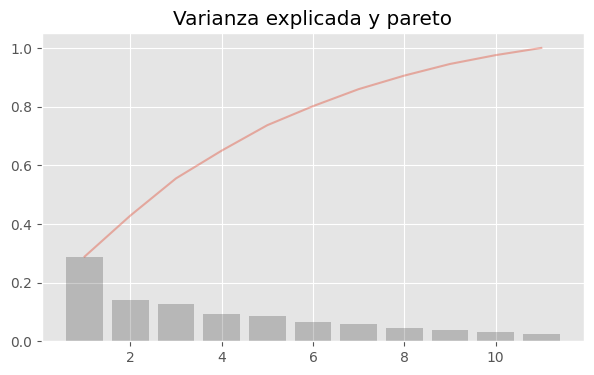

In [106]:
for i in range(len(pca.components_)):
    print('% Var. explicada ('+str(i+1)+' componentes): ', np.cumsum(pca.explained_variance_ratio_)[i]*100)
    
plt.bar(range(1,len(pca.components_)+1),pca.explained_variance_ratio_, alpha=.2,color='0')
plt.plot(range(1,len(pca.components_)+1),np.cumsum(pca.explained_variance_ratio_),alpha=0.4)
plt.title("Varianza explicada y pareto")
plt.show()

Según el gráfico podemos observar que hay tendencia a que cada componente aporta información relevante, por lo que no existe alguna relación fuerte entre variables

Lo que se puede deducir que cada variable independiente aporta, pero agrupandolos no tienen el mismo impacto.

En conclusión se debe quedar con las variables originales, ya que el PCA no tiene un aporte significativo

In [107]:
# Elegimos la componente adecuada:
pcaFin = PCA(n_components=11)
pcaFin.fit(dataFrame[channelName])
pd.DataFrame(pcaFin.components_,columns=channelName)

,trxAplus,trxBcaex,trxSalex,trxBm,trxBxi,trxIvr,trxSbt,trxVent,trxAtm,trxPostc,trxPostd
0,0.026809,0.232209,0.084654,0.182008,0.143405,0.097648,0.234063,0.062659,0.819368,0.028745,0.379560
1,0.027588,-0.486697,0.017398,0.209237,0.218755,0.200451,0.683125,0.163246,-0.272802,0.167809,0.185358
2,0.024185,0.817795,0.071716,0.137108,0.056873,0.185287,0.351097,-0.083352,-0.361613,0.044601,-0.078423
3,0.033558,-0.004203,0.644902,-0.402488,-0.155881,0.080668,0.169701,0.448182,0.131600,0.028044,-0.377338
4,-0.009256,0.047208,0.515373,0.359868,0.137236,-0.194606,-0.383046,0.298640,-0.281583,-0.028659,0.479423
5,-0.004722,0.155988,-0.537730,0.040147,0.084930,-0.103961,-0.064701,0.808110,-0.003571,0.041795,-0.088722
6,0.006937,-0.091644,0.078422,0.774632,-0.345628,-0.044739,0.009631,0.009916,0.137517,-0.016019,-0.494499
7,0.044889,0.017523,0.092333,0.025875,0.683380,-0.583102,0.072623,-0.131109,0.077323,0.159455,-0.357209
8,-0.086026,-0.065637,0.037403,0.101794,0.529849,0.706486,-0.349110,0.017068,0.036251,-0.100882,-0.251012
9,0.975895,-0.012538,-0.025012,0.003688,-0.006570,0.091636,-0.114336,-0.013197,-0.009991,0.158215,0.003731


Confirmamos nuestra evidencia en el gráfico de Pareto, donde: Para cada variable está asignado a cada Componente, Por tanto no existe reducción de dimensiones para nuestro estudio de canales de transacción

#### 3.6 Modelamiento

In [109]:
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import pairwise_distances_argmin_min 

c:\Users\dg_su\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\dg_su\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


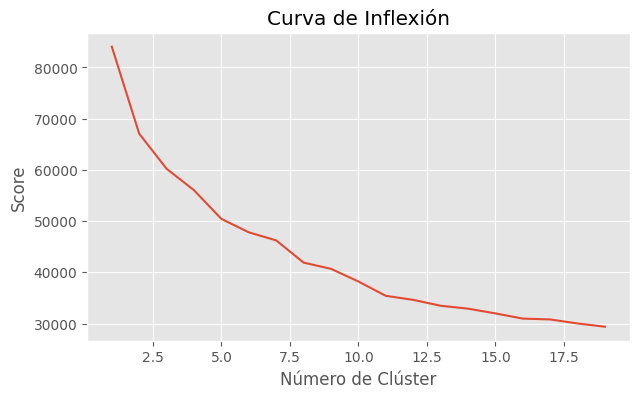

In [110]:
# Calculando el número de clúster adecuado:
X = dataFrame[channelName]

numClus = range(1, 20) #se va a probar de 1 hasta 20 clusters
kmeans = [KMeans(n_clusters=i,max_iter=600) for i in numClus]
kmeans
score = [kmeans[i].fit(X).score(X)*-1 for i in range(len(kmeans))]
score #suma de errores cuadraticos del error con respecto a su centroide,
plt.plot(numClus,score)
plt.xlabel('Número de Clúster')
plt.ylabel('Score')
plt.title('Curva de Inflexión')
plt.show()

Se puede apreciar que dibuja una curva casi perfecta, lo cual nos indica que esta data en particular no se presta para la segmentación, se esperaria una especie de codo una caida prolongada

In [111]:
# Nos fijamos de los indicadores de clustering:

ctdDf = int(0.1*dataFrame.shape[0])
cluster = [kmeans[i].predict(X) for i in range(len(kmeans))]

for i in range(1,11):    
    print(str(i+1)+' clústeres:')
    print('Inercia: '+str(kmeans[i].inertia_))
    print('Silueta: '+str(metrics.silhouette_score(X, cluster[i], metric='euclidean',sample_size=ctdDf)))
    print("\n")

2 clústeres:
Inercia: 67067.48926593577
Silueta: 0.3651261284764742


3 clústeres:
Inercia: 60223.828258363086
Silueta: 0.3704433235287895


4 clústeres:
Inercia: 56031.95607830508
Silueta: 0.3562830594475086


5 clústeres:
Inercia: 50435.189755209394
Silueta: 0.34114605696208555


6 clústeres:
Inercia: 47814.42511861933
Silueta: 0.2523898603510636


7 clústeres:
Inercia: 46239.07155711203
Silueta: 0.3051034064497341


8 clústeres:
Inercia: 41903.61361026091
Silueta: 0.33136264042652314


9 clústeres:
Inercia: 40686.739821907606
Silueta: 0.254526387518142


10 clústeres:
Inercia: 38217.7786788644
Silueta: 0.25820213950820103


11 clústeres:
Inercia: 35419.2829397347
Silueta: 0.2737746951923651




Mientras mas grande la silueta mejor es la segmentación  

Con los valores obtenidos se puede observar que del cluster 6 al cluster 7 hay una caida "abrupta" en la silueta lo cual nos indica que este valor de cluster puede ser idoneo para realizar la segmentación, se va a trabajar con 6 clusters

Visualizando los grupos en 2-D para tener alguna noción de como se agrupan, en esta ocasión probaremos distintos par de variables

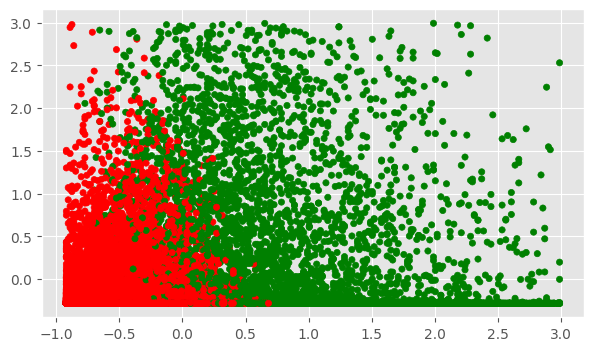

In [114]:
fig = plt.figure()
f1 = dataFrame['trxAtm'].values
f2 = dataFrame['trxBm'].values
 
#colores=['red','green','blue','cyan','yellow']
colores=['red','green','blue']
asignar=[]
for row in cluster[1]:
    asignar.append(colores[row])
    
plt.scatter(f1, f2, c=asignar, s=20)
#plt.scatter(centroide[2][:, 0], centroide[2][:, 1], marker='*', c='yellow', s=100)
plt.show()

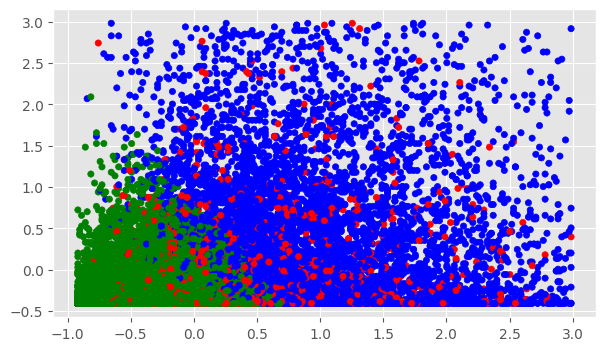

In [115]:
fig = plt.figure()
f1 = dataFrame['trxAtm'].values
f2 = dataFrame['trxPostd'].values
 
#colores=['red','green','blue','cyan','yellow']
colores=['red','green','blue']
asignar=[]
for row in cluster[2]:
    asignar.append(colores[row])
    
plt.scatter(f1, f2, c=asignar, s=20)
#plt.scatter(centroide[2][:, 0], centroide[2][:, 1], marker='*', c='yellow', s=100)
plt.show()

se puede ver que los datos se mezclan lo cual no es adecuado

#### 3.7 Evaluación

In [116]:
numClus = [5,6,7]

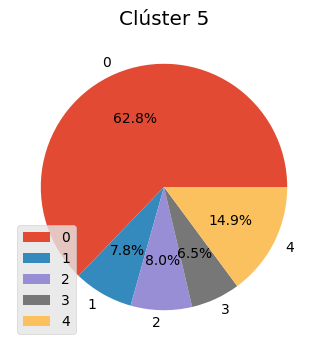

         ctdCliente  pctCliente
cluster                        
0             21725       62.81
1              2705        7.82
2              2780        8.04
3              2235        6.46
4              5143       14.87




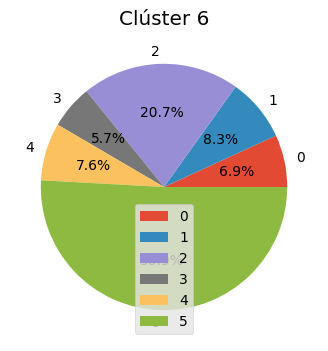

         ctdCliente  pctCliente
cluster                        
0              2369        6.85
1              2862        8.27
2              7163       20.71
3              1983        5.73
4              2619        7.57
5             17592       50.86




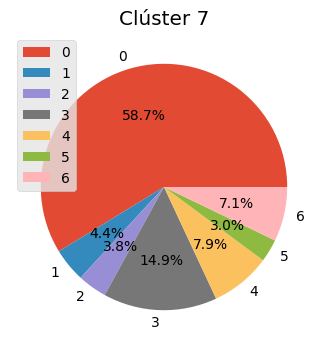

         ctdCliente  pctCliente
cluster                        
0             20316       58.74
1              1535        4.44
2              1328        3.84
3              5167       14.94
4              2736        7.91
5              1038        3.00
6              2468        7.14




In [117]:
centroide = [kmeans[i].cluster_centers_ for i in range(len(kmeans))]
copy =  pd.DataFrame()

for i in numClus:
    # Distribución de los grupos por clúster:
    copy['cluster'] = cluster[i-1]
    cantidadGrupo =  pd.DataFrame()
    cantidadGrupo['ctdCliente']=copy.groupby('cluster').size()
    cantidadGrupo['pctCliente']=round(100*cantidadGrupo['ctdCliente']/cantidadGrupo['ctdCliente'].sum(),2)
    
    # gráfico de los grupos según su distribución:
    plt.pie(cantidadGrupo['pctCliente'], labels=cantidadGrupo.index, autopct='%1.1f%%')
    plt.title('Clúster '+str(i))
    plt.legend()
    plt.show()
    print(cantidadGrupo)       
    print('\n')

Escojer aquellos cluster que no tengan segmentos muy pequeños

In [118]:
numClusFinal = int(input('Ingrese el número de clúster: '))

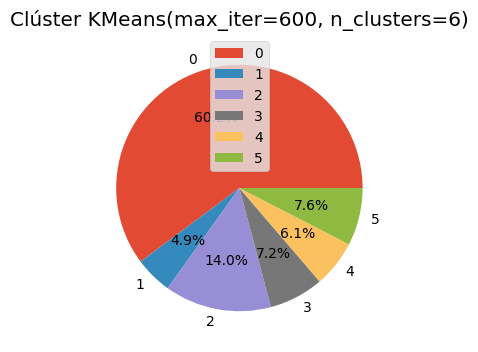

         ctdCliente  pctCliente
cluster                        
0             20822       60.20
1              1701        4.92
2              4845       14.01
3              2479        7.17
4              2127        6.15
5              2614        7.56




In [119]:
kmeans_fin = KMeans(n_clusters=numClusFinal,max_iter=600).fit(X)
cluster = pd.DataFrame(kmeans_fin.predict(X))
cluster.columns = ['cluster']

centroide = kmeans_fin.cluster_centers_
# Distribución de los grupos por clúster:
cantidadGrupo =  pd.DataFrame()
cantidadGrupo['ctdCliente']=cluster.groupby('cluster').size()
cantidadGrupo['pctCliente']=round(100*cantidadGrupo['ctdCliente']/cantidadGrupo['ctdCliente'].sum(),2)

# gráfico de los grupos según su distribución:
plt.pie(cantidadGrupo['pctCliente'], labels=cantidadGrupo.index, autopct='%1.1f%%')
plt.title('Clúster '+str(kmeans_fin))
plt.legend()
plt.show()
print(cantidadGrupo)       
print('\n')

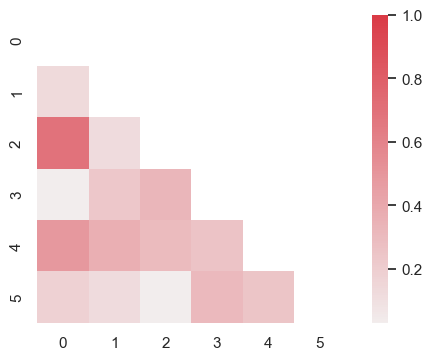

In [120]:
dfTransp = pd.DataFrame(centroide,columns=channelName).T
corr = dfTransp.corr()

def plot_correlations(corr):
    sns.set(style="white")
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(abs(corr), mask=mask, cmap=cmap, vmax=1, center=0,square=True) 
    
plot_correlations(corr)

la matriz de correlación de segmetos nos ayuda a identificar si podemos agrupar algunas variables, mientras mas correlacionadas esten mejor (mientras mas rojo mejor)

In [121]:
dfTransp

,0,1,2,3,4,5
trxAplus,-0.068693,-0.028420,-0.038292,0.006275,-0.032808,-0.043385
trxBcaex,-0.292796,-0.118336,-0.181139,-0.223868,-0.087505,1.484387
trxSalex,-0.223855,1.473479,-0.181731,-0.145886,-0.118226,-0.136140
trxBm,-0.221072,-0.198457,-0.212723,-0.028621,0.736099,-0.093969
trxBxi,-0.175303,-0.156181,-0.137111,0.086167,0.415135,-0.110346
trxIvr,-0.188013,-0.130543,-0.127310,0.364575,-0.038472,-0.074537
trxSbt,-0.345684,-0.186787,-0.193158,1.183639,0.150880,-0.210838
trxVent,-0.136206,0.190471,-0.050117,-0.021291,0.003656,-0.193305
trxAtm,-0.530059,-0.115124,1.046534,-0.273670,0.682200,0.041798
trxPostc,-0.152168,-0.127257,-0.144164,0.155953,-0.050424,-0.164301


In [123]:
# revisando los promedios en la data original
data_orig['cluster'] = cluster
data_orig.groupby('cluster')[channelName].mean().T

cluster,0,1,2,3,4,5
trxAplus,0.264816,0.515579,0.453044,0.731747,0.488011,0.422341
trxBcaex,1.273893,3.201646,2.504025,2.035498,3.542548,20.912012
trxSalex,0.864326,19.362728,1.319917,1.713594,2.014104,1.819816
trxBm,50.424455,68.536743,56.964912,204.772892,817.817113,152.353481
trxBxi,31.246326,41.795414,52.219401,175.663171,357.233662,67.113619
trxIvr,1.010374,1.910641,1.957276,9.670835,3.352139,2.788447
trxSbt,1.035539,2.105820,2.058824,11.339653,4.379878,1.943764
trxVent,1.643598,4.574368,2.410733,2.674062,2.896568,1.130451
trxAtm,26.449332,54.734274,133.718060,43.938685,109.001881,65.419281
trxPostc,0.775718,1.613757,1.042312,11.146430,4.197931,0.366871


#### 3.8 Perfilamiento

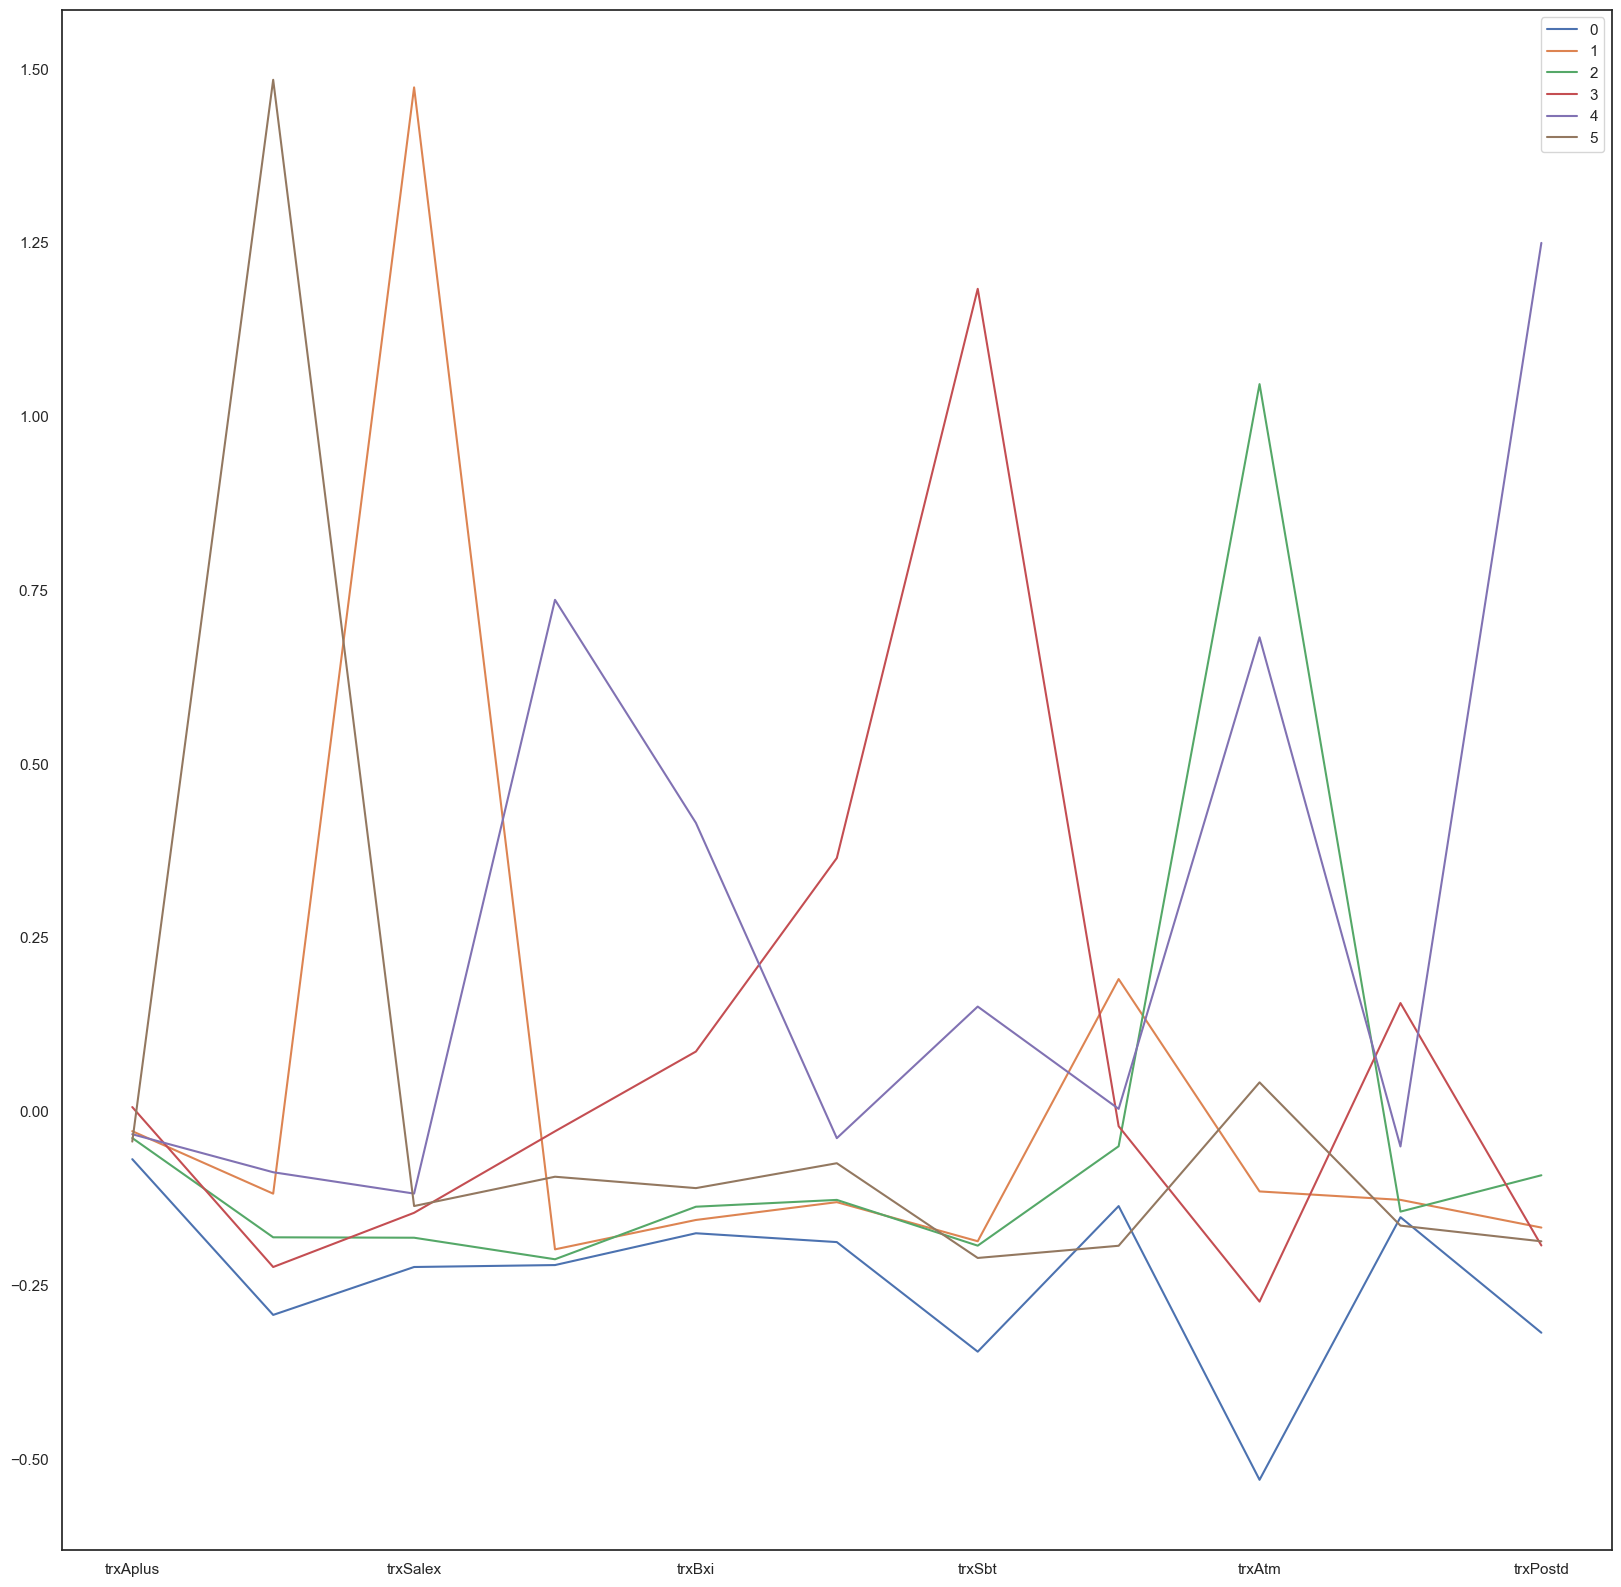

In [124]:
dfTransp.plot(figsize=(20,20))
plt.show()